<a href="https://colab.research.google.com/github/Yeabebe/Advanced-React-To-Do-List/blob/main/VAE_MNIST_FULL_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports & Setup

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Model

In [ ]:
class VAE_Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE_Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class VAE_Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(VAE_Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z = F.relu(self.fc1(z))
        z = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(z))

class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VAE_Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = VAE_Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


Hyperparameters and Setup

In [ ]:
input_dim = 28 * 28
hidden_dim = 256
latent_dim = 20
batch_size = 128
epochs = 10
learning_rate = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Load Data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:15<00:00, 630kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 169kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 268kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]


Train the VAE

In [ ]:
model = VariationalAutoencoder(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        total_loss += loss.item()
        optimizer.step()
    avg_loss = total_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 186.8035
Epoch 2, Loss: 136.4388
Epoch 3, Loss: 123.2495
Epoch 4, Loss: 116.8959
Epoch 5, Loss: 113.4999
Epoch 6, Loss: 111.0243
Epoch 7, Loss: 109.2684
Epoch 8, Loss: 107.8993
Epoch 9, Loss: 106.9318
Epoch 10, Loss: 106.0440


Evaluation

In [ ]:
model.eval()
test_loss = 0

with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)

        recon, mu, logvar = model(data)
        loss = vae_loss_function(recon, data, mu, logvar)

        test_loss += loss.item()

test_loss /= len(test_loader.dataset)

print(f"Test Loss: {test_loss:.4f}")

Plot Loss

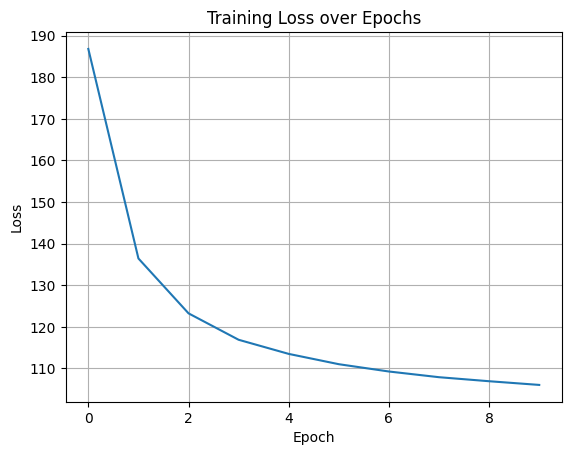

In [ ]:
plt.plot(loss_history)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


Visualize Reconstructions

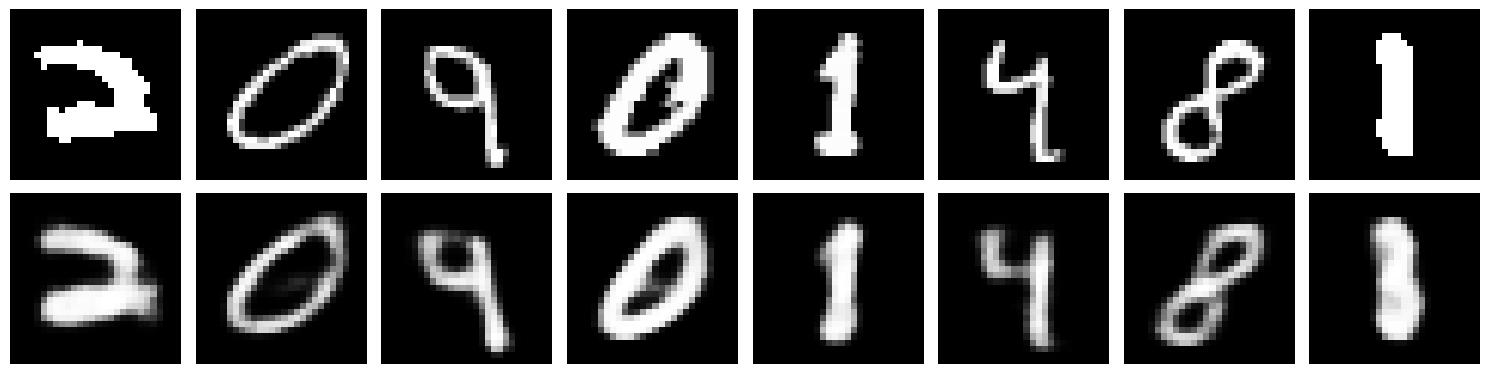

In [ ]:
model.eval()
test_samples = next(iter(train_loader))[0][:8].to(device)
with torch.no_grad():
    recon_samples, _, _ = model(test_samples)
test_samples = test_samples.view(-1, 1, 28, 28).cpu()
recon_samples = recon_samples.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i in range(8):
    axes[0, i].imshow(test_samples[i][0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_samples[i][0], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstruction', fontsize=12)
plt.tight_layout()
plt.show()
